<a href="https://colab.research.google.com/github/Bhupinder-2004/FCC_projects/blob/main/medical_data_visualizer_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

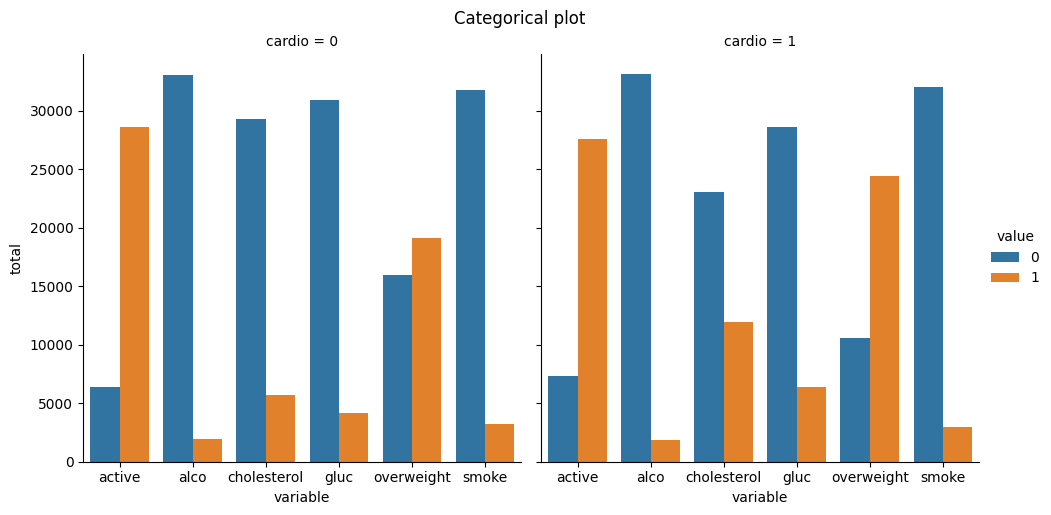

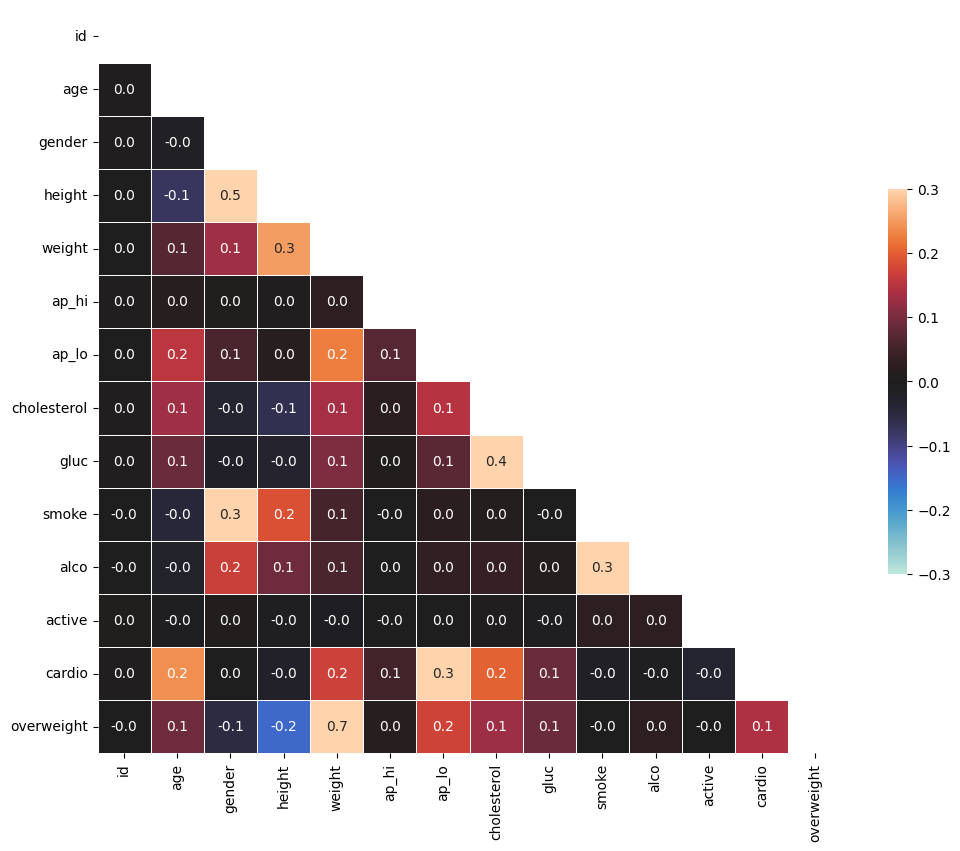

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def draw_cat_plot():

    df = pd.read_csv("medical_examination.csv.txt")

    bmi = df['weight'] / ((df['height'] / 100) ** 2)
    df['overweight'] = (bmi > 25).astype(int)

    df['cholesterol'] = (df['cholesterol'] > 1).astype(int)
    df['gluc'] = (df['gluc'] > 1).astype(int)

    df_cat = pd.melt(
        df,
        id_vars=['cardio'],
        value_vars=['cholesterol', 'gluc', 'smoke', 'alco', 'active', 'overweight']
    )

    df_cat = df_cat.groupby(['cardio', 'variable', 'value']).size().reset_index(name='total')

    catplot = sns.catplot(
        x='variable',
        y='total',
        hue='value',
        col='cardio',
        kind='bar',
        data=df_cat
    )

    fig = catplot.fig
    return fig


def draw_heat_map():

    df = pd.read_csv("medical_examination.csv.txt")

    bmi = df['weight'] / ((df['height'] / 100) ** 2)
    df['overweight'] = (bmi > 25).astype(int)

    df['cholesterol'] = (df['cholesterol'] > 1).astype(int)
    df['gluc'] = (df['gluc'] > 1).astype(int)

    df_heat = df[df['ap_lo'] <= df['ap_hi']]

    height_low = df_heat['height'].quantile(0.025)
    height_high = df_heat['height'].quantile(0.975)
    weight_low = df_heat['weight'].quantile(0.025)
    weight_high = df_heat['weight'].quantile(0.975)

    df_heat = df_heat[
        (df_heat['height'] >= height_low) &
        (df_heat['height'] <= height_high) &
        (df_heat['weight'] >= weight_low) &
        (df_heat['weight'] <= weight_high)
    ]

    corr = df_heat.corr()

    mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, ax = plt.subplots(figsize=(12, 10))

    sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        fmt='.1f',
        center=0,
        vmax=0.3,
        vmin=-0.3,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.5},
        ax=ax
    )
    return fig

if __name__ == "__main__":
    fig1 = draw_cat_plot()
    fig1.suptitle("Categorical plot", y=1.02)
    plt.show()


    fig2 = draw_heat_map()
    plt.show()
